# CC3092 – Deep Learning y Sistemas Inteligentes
## Laboratorio 9 — Modelos generativos: VAE y difusión

In [1]:
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets

# ----- Semilla reportada: todos los resultados del notebook usan SEED = 42 -----
SEED = 42


def fijar_semilla(seed=SEED):
    # Fija las fuentes de aleatoriedad de Python, NumPy y PyTorch (CPU y GPU).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


fijar_semilla(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("figuras", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

print(f"Semilla: {SEED}")
print(f"PyTorch {torch.__version__} | dispositivo: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Semilla: 42
PyTorch 2.14.1+cu130 | dispositivo: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


### Configuración

In [ ]:
# Task 1 — VAE
batch_size = 128
latent_dim = 2
epochs = 20
lr = 1e-3
beta_values = [0.1, 1.0, 10.0]

CLASES = ["Camiseta/top", "Pantalón", "Suéter", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"]

In [3]:
def mosaico(imgs, nfilas, ncols, pad=2, valor_pad=1.0):
    # Arma una cuadrícula (nfilas x ncols) de imágenes 28x28 en un solo arreglo para imshow.
    imgs = imgs.detach().float().cpu().reshape(-1, 28, 28)
    H, W = 28, 28
    lienzo = torch.full((nfilas * (H + pad) + pad, ncols * (W + pad) + pad), valor_pad)
    for k in range(min(len(imgs), nfilas * ncols)):
        i, j = divmod(k, ncols)
        r, c = pad + i * (H + pad), pad + j * (W + pad)
        lienzo[r:r + H, c:c + W] = imgs[k]
    return lienzo.numpy()


def guardar(nombre):
    # Guarda la figura actual en figuras/ (para el informe PDF) y la muestra en el notebook.
    plt.savefig(f"figuras/{nombre}.png", dpi=120, bbox_inches="tight")
    plt.show()

---
# Task 1 — Autoencoder variacional
## Task 1.1 — Datos

Se descarga Fashion-MNIST con la instrucción del enunciado. Los píxeles se escalan a $[0,1]$ dividiendo entre 255, y los **últimos 5 000** ejemplos de entrenamiento se separan como validación.

In [4]:
# Descarga con la instrucción del enunciado: datasets.FashionMNIST("data", train=True, download=True)
train_full = datasets.FashionMNIST("data", train=True, download=True)
test_set = datasets.FashionMNIST("data", train=False, download=True)

# Escalado a [0,1]: x = pixel / 255, con forma (N, 1, 28, 28)
X_all = train_full.data.float().div(255.0).unsqueeze(1)
y_all = train_full.targets.clone()

# Split: los últimos 5 000 ejemplos de entrenamiento son validación
X_train, y_train = X_all[:-5000], y_all[:-5000]
X_val, y_val = X_all[-5000:], y_all[-5000:]

# Todo el conjunto cabe en memoria de GPU (~170 MB), así se evita el costo de copiar cada lote.
X_train_d, X_val_d = X_train.to(device), X_val.to(device)
n_train, n_val = len(X_train), len(X_val)

print(f"Entrenamiento: {tuple(X_train.shape)} | Validación: {tuple(X_val.shape)} | Prueba: {len(test_set)}")
print(f"Rango de píxeles: [{X_all.min():.1f}, {X_all.max():.1f}]")
print("Ejemplos por clase en validación:", torch.bincount(y_val, minlength=10).tolist())

Entrenamiento: (55000, 1, 28, 28) | Validación: (5000, 1, 28, 28) | Prueba: 10000
Rango de píxeles: [0.0, 1.0]
Ejemplos por clase en validación: [521, 497, 490, 508, 527, 503, 467, 450, 515, 522]


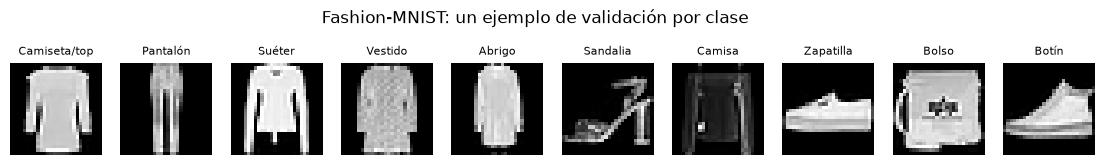

In [5]:
# Un ejemplo de validación por clase
fig, axes = plt.subplots(1, 10, figsize=(14, 1.8))
for c in range(10):
    idx = (y_val == c).nonzero()[0].item()
    axes[c].imshow(X_val[idx, 0], cmap="gray")
    axes[c].set_title(CLASES[c], fontsize=8)
    axes[c].axis("off")
plt.suptitle("Fashion-MNIST: un ejemplo de validación por clase", y=1.05)
guardar("t1_1_ejemplos")

## Task 1.2 — VAE: reparametrización, KL cerrada y pérdida $\mathcal L_\beta$

El encoder produce $\mu$ y $\log\sigma^2$, que son los parámetros de $q_\phi(z\mid x)=\mathcal N(\mu,\operatorname{diag}(\sigma^2))$. Las tres piezas pedidas son:

**a. Reparametrización** (Derivación 6):
$$\epsilon\sim\mathcal N(0,I),\qquad z=\mu+\sigma\odot\epsilon,\qquad \sigma=\exp\!\left(\tfrac12\log\sigma^2\right)$$

**b. KL cerrada** entre $q(z\mid x)$ y $p(z)=\mathcal N(0,I)$, sumada sobre las dimensiones latentes (Derivación 5):
$$D_{KL}=-\frac12\sum_{j=1}^{d}\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right)$$

**c. Pérdida por imagen**, con el error cuadrático sumado sobre los 784 píxeles:
$$\mathcal L_\beta=\lVert x-\hat x\rVert^2+\beta\,D_{KL}(q(z\mid x)\,\Vert\, p(z))$$

In [6]:
def reparametrizar(mu, logvar, generador=None):
    # (a) Truco de reparametrización: z = μ + σ ⊙ ε, con ε ~ N(0, I)
    #     σ = exp(½·log σ²), porque el encoder predice log σ² por estabilidad numérica.
    sigma = torch.exp(0.5 * logvar)
    eps = torch.randn(mu.shape, device=mu.device, dtype=mu.dtype, generator=generador)
    return mu + sigma * eps


def kl_cerrada(mu, logvar):
    # (b) KL(N(μ, diag σ²) || N(0, I)) = -½ Σ_j (1 + log σ_j² − μ_j² − σ_j²)
    #     Se suma sobre las dimensiones latentes, así que queda un valor por imagen.
    return -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp(), dim=1)


def error_reconstruccion(x, x_hat):
    # ||x − x̂||²: error cuadrático sumado sobre los 784 píxeles, un valor por imagen.
    return (x - x_hat).pow(2).flatten(1).sum(dim=1)


def perdida_vae(x, x_hat, mu, logvar, beta):
    # (c) L_β = ||x − x̂||² + β · D_KL, por imagen. Luego se promedia sobre el lote.
    rec = error_reconstruccion(x, x_hat)
    kl = kl_cerrada(mu, logvar)
    total = rec + beta * kl
    return total.mean(), rec.mean(), kl.mean()

**Arquitectura.** Se usa un VAE convolucional, con la misma arquitectura para los tres valores de $\beta$:

- **Encoder:** `Conv2d(1→32, k4, s2)` (28→14), luego `Conv2d(32→64, k4, s2)` (14→7), luego `Linear(3136→256)`, y de ahí dos cabezas `Linear(256→2)` que dan $\mu$ y $\log\sigma^2$.
- **Decoder:** `Linear(2→256)`, luego `Linear(256→3136)`, luego `ConvTranspose2d(64→32)` (7→14), luego `ConvTranspose2d(32→1)` (14→28) y al final una sigmoide, para que $\hat x\in[0,1]$ como los datos.

In [7]:
class VAEConv(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # Encoder q_φ(z|x): de la imagen a los parámetros (μ, log σ²) de una gaussiana diagonal
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)   # 28 -> 14
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.enc_fc = nn.Linear(64 * 7 * 7, 256)
        self.fc_mu = nn.Linear(256, latent_dim)       # μ_φ(x)
        self.fc_logvar = nn.Linear(256, latent_dim)   # log σ²_φ(x)
        # Decoder p_θ(x|z): de z a la media x̂ de la imagen
        self.dec_fc1 = nn.Linear(latent_dim, 256)
        self.dec_fc2 = nn.Linear(256, 64 * 7 * 7)
        self.dec_deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 7 -> 14
        self.dec_deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)   # 14 -> 28
        self.act = nn.ReLU()

    def encode(self, x):
        h = self.act(self.enc_conv1(x))
        h = self.act(self.enc_conv2(h))
        h = self.act(self.enc_fc(h.flatten(1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = self.act(self.dec_fc1(z))
        h = self.act(self.dec_fc2(h)).view(-1, 64, 7, 7)
        h = self.act(self.dec_deconv1(h))
        return torch.sigmoid(self.dec_deconv2(h))   # x̂ ∈ [0,1]

    def forward(self, x, generador=None):
        mu, logvar = self.encode(x)
        z = reparametrizar(mu, logvar, generador)    # z = μ + σ ⊙ ε
        return self.decode(z), mu, logvar


# Verificación de formas y de que la KL cerrada es no negativa
_m = VAEConv(latent_dim).to(device)
_x_hat, _mu, _lv = _m(X_train_d[:8])
assert _x_hat.shape == (8, 1, 28, 28) and _mu.shape == (8, latent_dim) and _lv.shape == (8, latent_dim)
assert torch.all(kl_cerrada(_mu, _lv) >= -1e-6)
assert torch.allclose(kl_cerrada(torch.zeros(1, 2), torch.zeros(1, 2)), torch.zeros(1))  # KL(N(0,I)||N(0,I)) = 0
print("Parámetros del VAE:", sum(p.numel() for p in _m.parameters()))
del _m, _x_hat, _mu, _lv

Parámetros del VAE: 1677509


In [8]:
@torch.no_grad()
def evaluar_vae(modelo, X, beta, lote=1000):
    # Error de reconstrucción y KL promedio por imagen en X. Se usa la misma pérdida que en
    # el entrenamiento, con z reparametrizado y un generador con semilla para que sea reproducible.
    modelo.eval()
    g = torch.Generator(device=device).manual_seed(SEED)
    s_rec = s_kl = 0.0
    for i in range(0, len(X), lote):
        xb = X[i:i + lote]
        x_hat, mu, logvar = modelo(xb, g)
        s_rec += error_reconstruccion(xb, x_hat).sum().item()
        s_kl += kl_cerrada(mu, logvar).sum().item()
    return s_rec / len(X), s_kl / len(X)


def entrenar_vae(beta):
    # Misma semilla para cada β: misma inicialización y mismo orden de lotes,
    # así la única diferencia entre los modelos es β.
    fijar_semilla(SEED)
    modelo = VAEConv(latent_dim).to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    g_lotes = torch.Generator().manual_seed(SEED)                     # orden de los mini-lotes
    g_ruido = torch.Generator(device=device).manual_seed(SEED + 1)    # ε de la reparametrización
    hist = {k: [] for k in ["rec_train", "kl_train", "rec_val", "kl_val"]}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        modelo.train()
        perm = torch.randperm(n_train, generator=g_lotes).to(device)
        s_rec = s_kl = 0.0
        for i in range(0, n_train, batch_size):
            xb = X_train_d[perm[i:i + batch_size]]
            x_hat, mu, logvar = modelo(xb, g_ruido)
            loss, rec, kl = perdida_vae(xb, x_hat, mu, logvar, beta)   # L_β promedio del lote
            opt.zero_grad()
            loss.backward()
            opt.step()
            s_rec += rec.item() * len(xb)
            s_kl += kl.item() * len(xb)
        rec_v, kl_v = evaluar_vae(modelo, X_val_d, beta)
        hist["rec_train"].append(s_rec / n_train)
        hist["kl_train"].append(s_kl / n_train)
        hist["rec_val"].append(rec_v)
        hist["kl_val"].append(kl_v)
        if ep == 1 or ep % 5 == 0:
            print(f"  β={beta:<4} época {ep:2d} | rec_val={rec_v:7.3f}  KL_val={kl_v:6.3f}"
                  f"  L_β val={rec_v + beta * kl_v:7.3f}  ({time.time() - t0:5.1f}s)")
    torch.save(modelo.state_dict(), f"checkpoints/vae_beta{beta}.pt")
    modelo.eval()
    return modelo, hist


modelos, historiales = {}, {}
for beta in beta_values:
    print(f"Entrenando VAE con β = {beta}")
    modelos[beta], historiales[beta] = entrenar_vae(beta)

Entrenando VAE con β = 0.1


  β=0.1  época  1 | rec_val= 26.101  KL_val= 7.733  L_β val= 26.874  (  3.7s)


  β=0.1  época  5 | rec_val= 22.347  KL_val= 7.985  L_β val= 23.145  ( 16.7s)


  β=0.1  época 10 | rec_val= 21.256  KL_val= 8.282  L_β val= 22.084  ( 33.3s)


  β=0.1  época 15 | rec_val= 20.914  KL_val= 8.050  L_β val= 21.719  ( 49.6s)


...

  β=10.0 época  1 | rec_val= 39.937  KL_val= 1.552  L_β val= 55.457  (  3.2s)


  β=10.0 época  5 | rec_val= 36.127  KL_val= 1.841  L_β val= 54.534  ( 16.1s)


  β=10.0 época 10 | rec_val= 36.710  KL_val= 1.721  L_β val= 53.921  ( 32.0s)


  β=10.0 época 15 | rec_val= 36.655  KL_val= 1.709  L_β val= 53.742  ( 47.8s)


  β=10.0 época 20 | rec_val= 36.599  KL_val= 1.721  L_β val= 53.804  ( 64.0s)


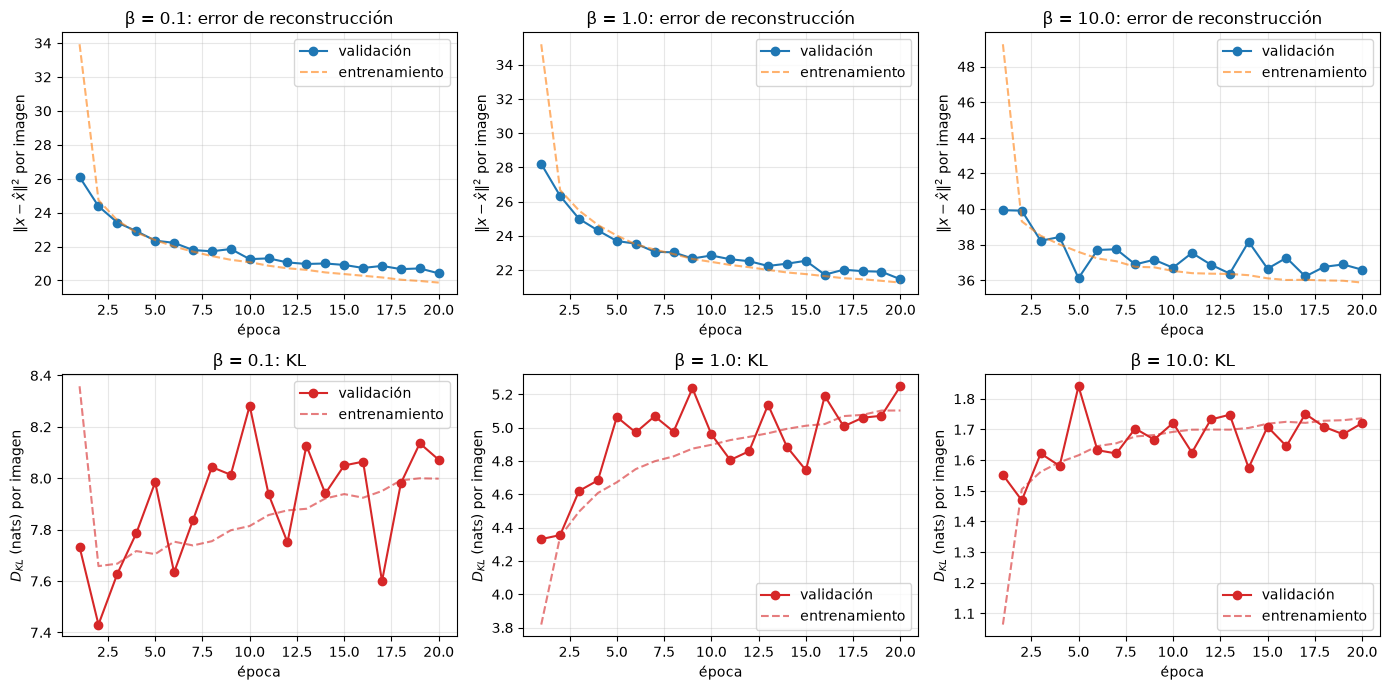

In [9]:
# Curvas de validación por época: error de reconstrucción (fila 1) y KL (fila 2), una columna por β
ep_ax = np.arange(1, epochs + 1)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for j, beta in enumerate(beta_values):
    h = historiales[beta]
    axes[0, j].plot(ep_ax, h["rec_val"], "o-", label="validación")
    axes[0, j].plot(ep_ax, h["rec_train"], "--", alpha=0.6, label="entrenamiento")
    axes[0, j].set_title(f"β = {beta}: error de reconstrucción")
    axes[0, j].set_ylabel(r"$\|x-\hat x\|^2$ por imagen")
    axes[1, j].plot(ep_ax, h["kl_val"], "o-", color="C3", label="validación")
    axes[1, j].plot(ep_ax, h["kl_train"], "--", color="C3", alpha=0.6, label="entrenamiento")
    axes[1, j].set_title(f"β = {beta}: KL")
    axes[1, j].set_ylabel(r"$D_{KL}$ (nats) por imagen")
    for i in range(2):
        axes[i, j].set_xlabel("época")
        axes[i, j].legend()
        axes[i, j].grid(alpha=0.3)
plt.tight_layout()
guardar("t1_2_curvas_validacion")

## Task 1.3 — Figuras del espacio latente y generación
### a. Dispersión de $\mu$ en validación, coloreada por clase

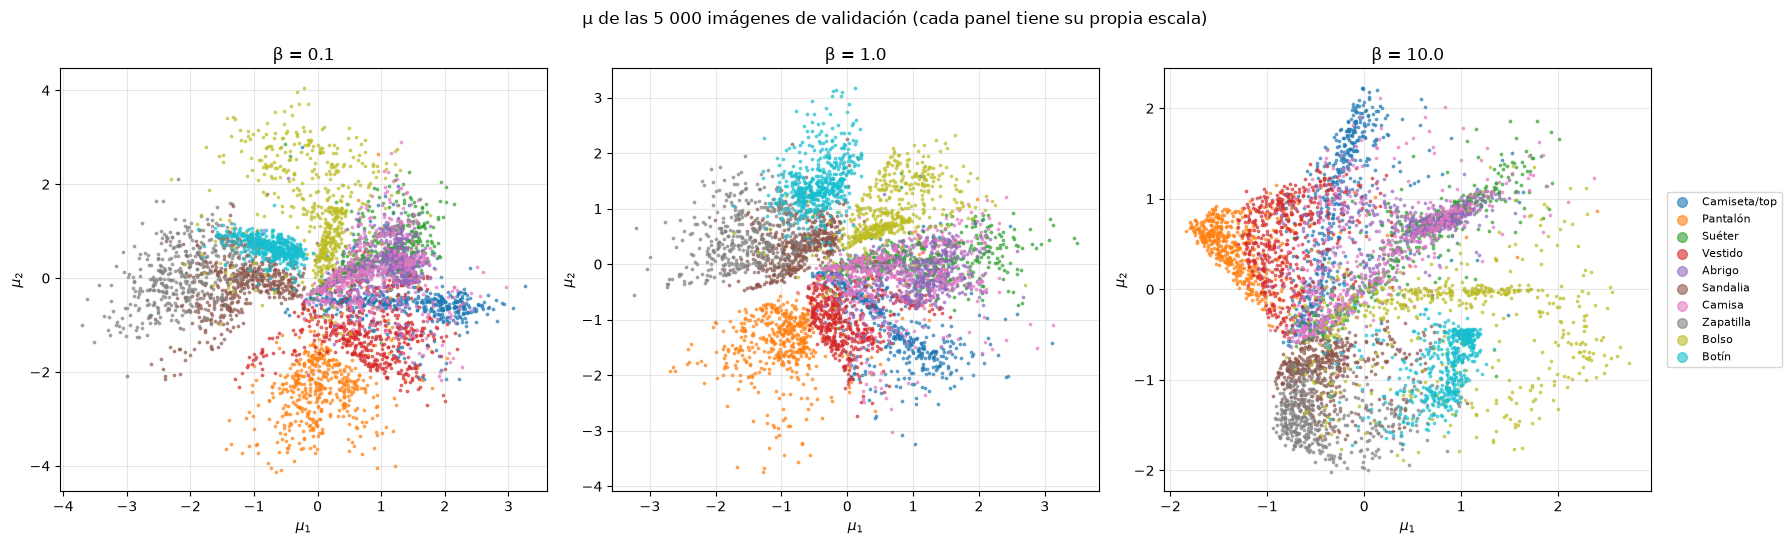

β=0.1 : rango μ1=[-3.70, 3.26]  μ2=[-4.13, 4.06]  σ² promedio=[0.0006 0.0012]
β=1.0 : rango μ1=[-3.23, 3.49]  μ2=[-3.74, 3.18]  σ² promedio=[0.0091 0.0095]
β=10.0: rango μ1=[-1.83, 2.73]  μ2=[-2.01, 2.23]  σ² promedio=[0.2375 0.162 ]


In [10]:
@torch.no_grad()
def codificar_mu(modelo, X, lote=1000):
    # Devuelve μ_φ(x) y log σ²_φ(x) para todo X, la media y log-varianza de q(z|x).
    mus, lvs = [], []
    for i in range(0, len(X), lote):
        mu, lv = modelo.encode(X[i:i + lote])
        mus.append(mu)
        lvs.append(lv)
    return torch.cat(mus), torch.cat(lvs)


mu_val, logvar_val = {}, {}
for beta in beta_values:
    mu_val[beta], logvar_val[beta] = codificar_mu(modelos[beta], X_val_d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, beta in zip(axes, beta_values):
    m = mu_val[beta].cpu()
    for c in range(10):
        sel = y_val == c
        ax.scatter(m[sel, 0], m[sel, 1], s=3, alpha=0.6, color=plt.cm.tab10(c), label=CLASES[c])
    ax.set_title(f"β = {beta}")
    ax.set_xlabel(r"$\mu_1$")
    ax.set_ylabel(r"$\mu_2$")
    ax.grid(alpha=0.3)
axes[2].legend(markerscale=4, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.suptitle("μ de las 5 000 imágenes de validación (cada panel tiene su propia escala)")
plt.tight_layout()
guardar("t1_3a_dispersion_mu")

for beta in beta_values:
    m = mu_val[beta]
    print(f"β={beta:<4}: rango μ1=[{m[:, 0].min():.2f}, {m[:, 0].max():.2f}]  "
          f"μ2=[{m[:, 1].min():.2f}, {m[:, 1].max():.2f}]  "
          f"σ² promedio={logvar_val[beta].exp().mean(0).cpu().numpy().round(4)}")

### b. $\beta=1$: decodificación sobre una cuadrícula regular $15\times15$ en $[-3,3]^2$

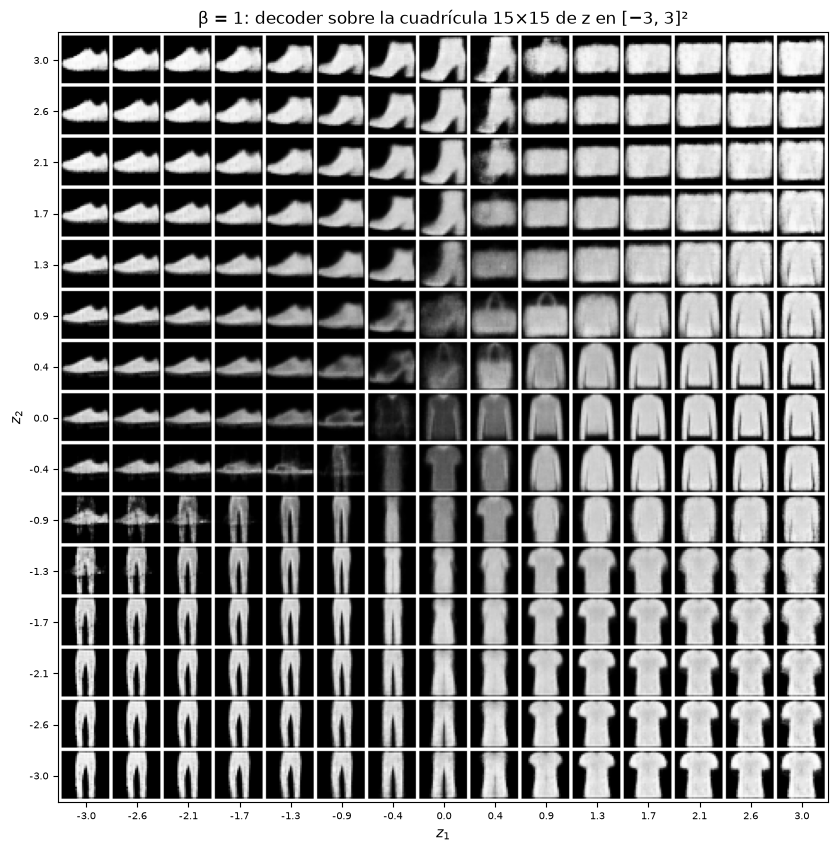

In [11]:
vae1 = modelos[1.0]
valores = torch.linspace(-3, 3, 15)
# Fila i corresponde a z2 (de +3 arriba a −3 abajo); columna j corresponde a z1 (de −3 a +3)
z_rejilla = torch.stack([torch.stack([valores[j], valores[14 - i]])
                         for i in range(15) for j in range(15)]).to(device)
with torch.no_grad():
    img_rejilla = vae1.decode(z_rejilla)

plt.figure(figsize=(10, 10))
paso = 30   # 28 píxeles + 2 de separación
plt.imshow(mosaico(img_rejilla, 15, 15), cmap="gray")
plt.xticks(2 + 14 + paso * np.arange(15), [f"{v:.1f}" for v in valores.tolist()], fontsize=7)
plt.yticks(2 + 14 + paso * np.arange(15), [f"{v:.1f}" for v in valores.flip(0).tolist()], fontsize=7)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("β = 1: decoder sobre la cuadrícula 15×15 de z en [−3, 3]²")
guardar("t1_3b_rejilla_beta1")

### c. 64 imágenes generadas con $z\sim\mathcal N(0,I)$ para cada $\beta$

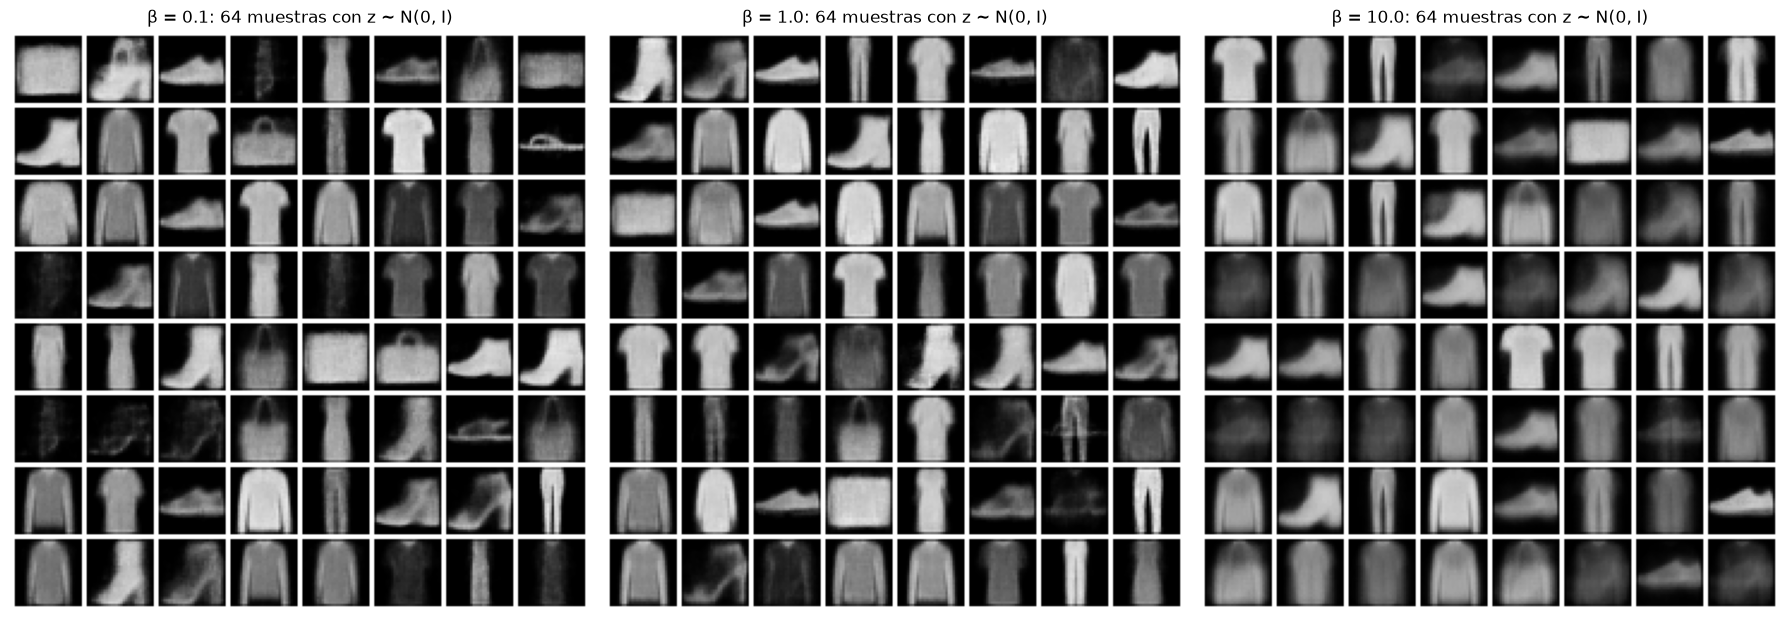

In [12]:
g_muestras = torch.Generator(device=device).manual_seed(SEED)
z_prior = torch.randn(64, latent_dim, device=device, generator=g_muestras)   # z ~ N(0, I)
fig, axes = plt.subplots(1, 3, figsize=(18, 6.3))
for ax, beta in zip(axes, beta_values):
    with torch.no_grad():
        muestras = modelos[beta].decode(z_prior)   # el mismo z para los tres β
    ax.imshow(mosaico(muestras, 8, 8), cmap="gray")
    ax.set_title(f"β = {beta}: 64 muestras con z ~ N(0, I)")
    ax.axis("off")
plt.tight_layout()
guardar("t1_3c_muestras_prior")

### d. $\beta=1$: interpolación en el espacio de píxeles frente al espacio latente

Se toman dos imágenes de validación de clases distintas (la primera *Pantalón* y el primer *Botín* del conjunto de validación). Con $\lambda\in\{0,\tfrac19,\dots,1\}$, es decir 8 puntos intermedios más los dos extremos:

- **Píxeles:** $x_\lambda=(1-\lambda)\,x_a+\lambda\,x_b$
- **Latente:** $z_\lambda=(1-\lambda)\,\mu_a+\lambda\,\mu_b$, y se muestra $\hat x_\lambda=\text{decoder}(z_\lambda)$

Imagen A: índice de validación 22 (Pantalón), μ_a = [[-0.849 -0.97 ]]
Imagen B: índice de validación 13 (Botín), μ_b = [[-0.727  1.364]]


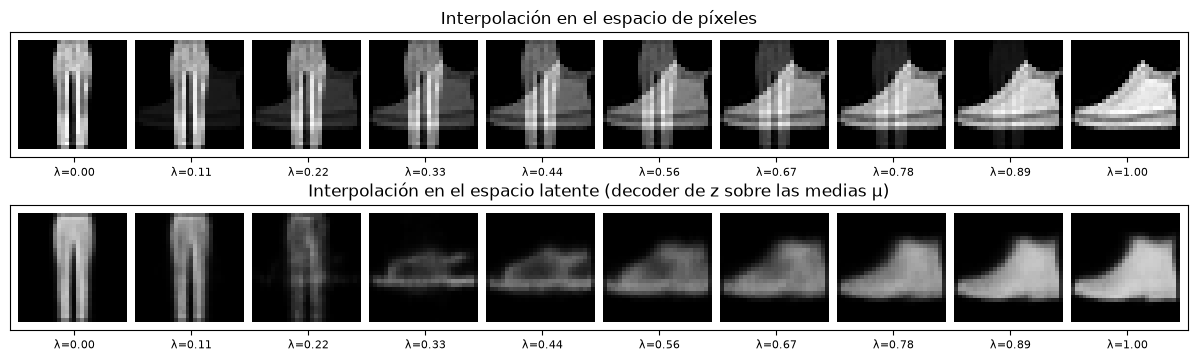

In [13]:
idx_a = (y_val == 1).nonzero()[0].item()   # primer "Pantalón" de validación
idx_b = (y_val == 9).nonzero()[0].item()   # primer "Botín" de validación
x_a, x_b = X_val_d[idx_a:idx_a + 1], X_val_d[idx_b:idx_b + 1]
lambdas = torch.linspace(0, 1, 10, device=device).view(-1, 1)   # 8 puntos intermedios + 2 extremos

with torch.no_grad():
    interp_pix = (1 - lambdas.view(-1, 1, 1, 1)) * x_a + lambdas.view(-1, 1, 1, 1) * x_b   # en píxeles
    mu_a, _ = vae1.encode(x_a)
    mu_b, _ = vae1.encode(x_b)
    z_interp = (1 - lambdas) * mu_a + lambdas * mu_b                                      # sobre las medias μ
    interp_lat = vae1.decode(z_interp)

print(f"Imagen A: índice de validación {idx_a} ({CLASES[1]}), μ_a = {mu_a.cpu().numpy().round(3)}")
print(f"Imagen B: índice de validación {idx_b} ({CLASES[9]}), μ_b = {mu_b.cpu().numpy().round(3)}")

fig, axes = plt.subplots(2, 1, figsize=(14, 3.6))
axes[0].imshow(mosaico(interp_pix, 1, 10), cmap="gray")
axes[0].set_title("Interpolación en el espacio de píxeles")
axes[1].imshow(mosaico(interp_lat, 1, 10), cmap="gray")
axes[1].set_title("Interpolación en el espacio latente (decoder de z sobre las medias μ)")
for ax in axes:
    ax.set_xticks(2 + 14 + 30 * np.arange(10), [f"λ={l:.2f}" for l in lambdas.flatten().tolist()], fontsize=8)
    ax.set_yticks([])
plt.tight_layout()
guardar("t1_3d_interpolaciones")

## Task 1.4 — Análisis
### a. Tabla de reconstrucción y KL de validación finales, con la KL en bits

In [14]:
LOG2_10 = math.log2(10)
print(f"{'β':>5} | {'rec. val':>9} | {'KL (nats)':>9} | {'KL (bits)':>9} | {'KL/log2(10)':>11}")
print("-" * 57)
tabla_14a = {}
for beta in beta_values:
    rec_f = historiales[beta]["rec_val"][-1]
    kl_f = historiales[beta]["kl_val"][-1]
    kl_bits = kl_f / math.log(2)          # bits = nats / ln 2
    tabla_14a[beta] = (rec_f, kl_f, kl_bits)
    print(f"{beta:>5} | {rec_f:9.3f} | {kl_f:9.3f} | {kl_bits:9.3f} | {kl_bits / LOG2_10:11.3f}")
print(f"\nBits necesarios para identificar la clase: log2(10) = {LOG2_10:.3f}")

    β |  rec. val | KL (nats) | KL (bits) | KL/log2(10)
---------------------------------------------------------
  0.1 |    20.417 |     8.072 |    11.645 |       3.506
  1.0 |    21.457 |     5.248 |     7.572 |       2.279
 10.0 |    36.599 |     1.721 |     2.482 |       0.747

Bits necesarios para identificar la clase: log2(10) = 3.322


Como evidencia adicional de cuánta información de clase lleva el código latente, se clasifica cada imagen de validación por el **centroide de clase más cercano** en el espacio de $\mu$. Los centroides se calculan con las $\mu$ del conjunto de entrenamiento.

In [15]:
@torch.no_grad()
def exactitud_centroide(beta):
    # Clasificador de centroide más cercano en el espacio μ (centroides de entrenamiento, evaluado en validación)
    mu_tr, _ = codificar_mu(modelos[beta], X_train_d)
    y_tr = y_train.to(device)
    centroides = torch.stack([mu_tr[y_tr == c].mean(0) for c in range(10)])
    d = (mu_val[beta][:, None, :] - centroides[None, :, :]).pow(2).sum(-1)
    return (d.argmin(1).cpu() == y_val).float().mean().item()


for beta in beta_values:
    print(f"β={beta:<4}: exactitud por centroide más cercano en μ = {exactitud_centroide(beta):.3f} (azar = 0.100)")

β=0.1 : exactitud por centroide más cercano en μ = 0.639 (azar = 0.100)
β=1.0 : exactitud por centroide más cercano en μ = 0.664 (azar = 0.100)
β=10.0: exactitud por centroide más cercano en μ = 0.527 (azar = 0.100)


**Respuesta 1.4(a).**

| $\beta$ | Reconstrucción val. $\lVert x-\hat x\rVert^2$ | KL val. (nats) | KL val. (bits) | KL / $\log_2 10$ | Exactitud por centroide en $\mu$ |
|---:|---:|---:|---:|---:|---:|
| 0.1 | 20.417 | 8.072 | 11.645 | 3.51 | 0.639 |
| 1 | 21.457 | 5.248 | 7.572 | 2.28 | 0.664 |
| 10 | 36.599 | 1.721 | **2.482** | **0.75** | 0.527 |

Al subir $\beta$, la reconstrucción empeora (20.4 → 36.6) y la KL baja (8.07 → 1.72 nats), como se espera: $\beta$ pondera el costo de cada nat que el código latente transmite.

La KL promedio, $\mathbb E_x[D_{KL}(q(z\mid x)\Vert p(z))]$, es una cota superior de la información mutua $I(x;z)$ entre la imagen y su código. Con $\beta=10$, esa cota vale **2.48 bits**, menos que los $\log_2 10\approx3.32$ bits necesarios para identificar la clase. Por lo tanto, **el código latente de $\beta=10$ no puede transmitir la clase completa de la imagen**: como mucho distingue unos $2^{2.48}\approx5.6$ “mensajes” de forma fiable, no 10. Además, esos bits también se gastan en información que no es la clase, como el brillo o el grosor.

El diagrama de dispersión de $\beta=10$ (Task 1.3a) lo confirma:
- Hay unos cinco “brazos” bien separados: pantalón (izquierda), zapatilla/sandalia (abajo), botín (abajo a la derecha), bolso (derecha) y un brazo superior de prendas de torso.
- En cambio, camiseta, camisa, suéter, abrigo y vestido se enciman a lo largo de los mismos brazos.
- El clasificador de centroide más cercano en $\mu$ cae de 0.664 ($\beta=1$) a 0.527 ($\beta=10$).

Con $\beta=0.1$ (11.6 bits) y $\beta=1$ (7.6 bits) sobra capacidad para la clase. El exceso se usa en estilo dentro de cada clase, por eso bajar $\beta$ de 1 a 0.1 no mejora la exactitud por centroide (0.664 → 0.639).

### b. Verificación Monte Carlo de la KL cerrada

Para una imagen de validación y el modelo con $\beta=1$:
$$\widehat{D}_{KL}^{MC}=\frac1N\sum_{i=1}^{N}\left[\log q(z_i\mid x)-\log p(z_i)\right],\qquad z_i\sim q(z\mid x),\quad N=10^5$$
con log-densidades gaussianas escritas a mano: $\log\mathcal N(z;\mu,\sigma^2)=-\tfrac12\sum_j\left[\log 2\pi+\log\sigma_j^2+(z_j-\mu_j)^2/\sigma_j^2\right]$.

In [16]:
def log_normal_diag(z, mu, logvar):
    # log N(z; μ, diag σ²) = −½ Σ_j [ log 2π + log σ_j² + (z_j − μ_j)² / σ_j² ]
    return -0.5 * torch.sum(math.log(2 * math.pi) + logvar + (z - mu).pow(2) / logvar.exp(), dim=-1)


idx_mc = 0   # primera imagen de validación
with torch.no_grad():
    mu_mc, lv_mc = vae1.encode(X_val_d[idx_mc:idx_mc + 1])
mu_mc, lv_mc = mu_mc.double(), lv_mc.double()   # doble precisión para el estimador

N_MC = 100_000
g_mc = torch.Generator(device=device).manual_seed(SEED)
z_mc = reparametrizar(mu_mc.expand(N_MC, -1), lv_mc.expand(N_MC, -1), g_mc)    # z_i ~ q(z|x)
log_q = log_normal_diag(z_mc, mu_mc, lv_mc)
log_p = log_normal_diag(z_mc, torch.zeros_like(mu_mc), torch.zeros_like(lv_mc))   # p(z) = N(0, I)
dif = log_q - log_p

kl_mc = dif.mean().item()
ee_mc = (dif.std() / math.sqrt(N_MC)).item()            # error estándar = s / √N
kl_cf = kl_cerrada(mu_mc, lv_mc).item()
err_rel = abs(kl_mc - kl_cf) / kl_cf

print(f"Imagen de validación {idx_mc} ({CLASES[y_val[idx_mc]]}): μ = {mu_mc.cpu().numpy().round(4)}, "
      f"σ² = {lv_mc.exp().cpu().numpy().round(5)}")
print(f"KL cerrada            = {kl_cf:.5f} nats")
print(f"KL Monte Carlo (N=1e5) = {kl_mc:.5f} nats")
print(f"Error absoluto        = {abs(kl_mc - kl_cf):.5f}  | error relativo = {100 * err_rel:.4f} %")
print(f"Desv. est. de log q − log p = {dif.std().item():.4f}  ->  error estándar MC = {ee_mc:.5f} nats "
      f"({100 * ee_mc / kl_cf:.4f} % de la KL)")
print(f"|KL_MC − KL_cerrada| / EE = {abs(kl_mc - kl_cf) / ee_mc:.2f} errores estándar")

Imagen de validación 0 (Camiseta/top): μ = [[ 2.1203 -0.9745]], σ² = [[0.03899 0.01067]]
KL cerrada            = 5.63978 nats
KL Monte Carlo (N=1e5) = 5.64521 nats
Error absoluto        = 0.00543  | error relativo = 0.0963 %
Desv. est. de log q − log p = 1.0572  ->  error estándar MC = 0.00334 nats (0.0593 % de la KL)
|KL_MC − KL_cerrada| / EE = 1.62 errores estándar


**Respuesta 1.4(b).** Para la imagen de validación 0 (Camiseta/top), el modelo $\beta=1$ da $\mu=(2.1203,\,-0.9745)$ y $\sigma^2=(0.03899,\,0.01067)$.

| Cantidad | Valor |
|---|---:|
| KL cerrada | 5.63978 nats |
| KL Monte Carlo ($N=10^5$) | 5.64521 nats |
| Error absoluto | 0.00543 nats |
| Error relativo | **0.096 %** |
| Desv. estándar de $\log q-\log p$ | 1.0572 |
| Error estándar MC $=s/\sqrt N$ | 0.00334 nats (0.059 % de la KL) |

El estimador Monte Carlo es un promedio de $N$ variables i.i.d. con desviación estándar $s\approx1.057$. Por el teorema central del límite, su error típico es $s/\sqrt{N}=1.057/\sqrt{10^5}\approx0.0033$ nats. La diferencia observada es $0.00543/0.00334=$ **1.62 errores estándar**, dentro de la banda de $\pm1.96$ EE (95 %; un desvío así de grande o mayor ocurre con probabilidad ≈ 0.10). Por lo tanto, el error **sí es compatible** con la variabilidad esperada de una estimación Monte Carlo de ese tamaño, y la fórmula cerrada queda verificada. Para bajar el error relativo a 0.01 % harían falta unas $35$ veces más muestras, porque el error decrece como $1/\sqrt N$.

### c. Regiones no reconocibles del espacio latente e interpolaciones

Para ubicar regiones “vacías”, se superpone la cuadrícula $15\times15$ de la Task 1.3(b) sobre las $\mu$ de validación de $\beta=1$. Para cada punto de la cuadrícula se mide la distancia a la $\mu$ de validación más cercana. Además, para los puntos medios ($\lambda=0.44$ y $0.56$) de ambas interpolaciones se mide la distancia euclidiana a la imagen de entrenamiento más cercana, como indicador de qué tan “realista” es cada punto medio.

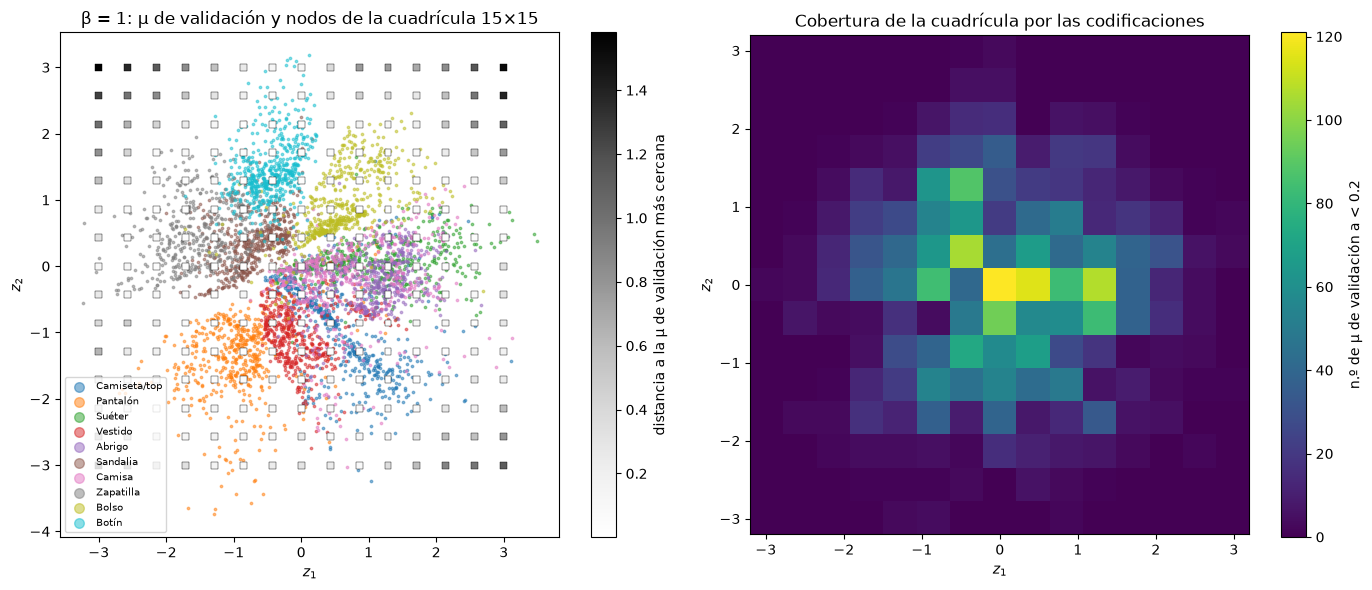

Nodos con ninguna μ a menos de 0.2: 80 de 225
  ||z|| ≤ 1.0:  21 nodos, vacíos =   0, distancia media a la μ más cercana = 0.026
  ||z|| ≤ 2.0:  69 nodos, vacíos =   0, distancia media a la μ más cercana = 0.036
  ||z|| ≤ 3.0: 149 nodos, vacíos =  15, distancia media a la μ más cercana = 0.083
  ||z|| ≤ 4.3: 225 nodos, vacíos =  80, distancia media a la μ más cercana = 0.251
Fracción de μ de validación con ||μ|| > 2: 0.139
Fracción de μ de validación con ||μ|| > 3: 0.009


In [17]:
with torch.no_grad():
    d_min = torch.cdist(z_rejilla, mu_val[1.0]).min(dim=1).values   # distancia de cada nodo a la μ más cercana
d_min_mat = d_min.view(15, 15).cpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
m = mu_val[1.0].cpu()
for c in range(10):
    sel = y_val == c
    axes[0].scatter(m[sel, 0], m[sel, 1], s=3, alpha=0.5, color=plt.cm.tab10(c), label=CLASES[c])
zr = z_rejilla.cpu()
sc = axes[0].scatter(zr[:, 0], zr[:, 1], c=d_min.cpu(), cmap="Greys", marker="s", s=25, edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=axes[0], label="distancia a la μ de validación más cercana")
axes[0].set_title("β = 1: μ de validación y nodos de la cuadrícula 15×15")
axes[0].set_xlabel(r"$z_1$")
axes[0].set_ylabel(r"$z_2$")
axes[0].legend(markerscale=4, fontsize=7, loc="lower left")

# Densidad del prior p(z) = N(0, I) frente a cuántas μ caen cerca de cada nodo (radio 0.2)
with torch.no_grad():
    cerca = (torch.cdist(z_rejilla, mu_val[1.0]) < 0.2).sum(1).view(15, 15).cpu()
im = axes[1].imshow(cerca, cmap="viridis", extent=[-3.2, 3.2, -3.2, 3.2])
plt.colorbar(im, ax=axes[1], label="n.º de μ de validación a < 0.2")
axes[1].set_title("Cobertura de la cuadrícula por las codificaciones")
axes[1].set_xlabel(r"$z_1$")
axes[1].set_ylabel(r"$z_2$")
plt.tight_layout()
guardar("t1_4c_cobertura_latente")

radio = torch.sqrt(z_rejilla.pow(2).sum(1)).cpu()
print(f"Nodos con ninguna μ a menos de 0.2: {(cerca.flatten() == 0).sum().item()} de 225")
for lim in [1.0, 2.0, 3.0, 4.3]:
    sel = radio <= lim
    print(f"  ||z|| ≤ {lim}: {sel.sum().item():3d} nodos, vacíos = {(cerca.flatten()[sel] == 0).sum().item():3d}, "
          f"distancia media a la μ más cercana = {d_min.cpu()[sel].mean():.3f}")
print(f"Fracción de μ de validación con ||μ|| > 2: {(mu_val[1.0].norm(dim=1) > 2).float().mean().item():.3f}")
print(f"Fracción de μ de validación con ||μ|| > 3: {(mu_val[1.0].norm(dim=1) > 3).float().mean().item():.3f}")

 λ    | dist. mín. a entrenamiento: píxeles | latente
 0.00 |                               1.878 |   1.810
 0.11 |                               2.374 |   1.977
 0.22 |                               3.183 |   2.310
 0.33 |                               4.255 |   2.433
 0.44 |                               5.359 |   2.583
 0.56 |                               5.189 |   2.602
 0.67 |                               4.313 |   2.838
 0.78 |                               3.821 |   2.612
 0.89 |                               3.495 |   2.448
 1.00 |                               3.554 |   2.402


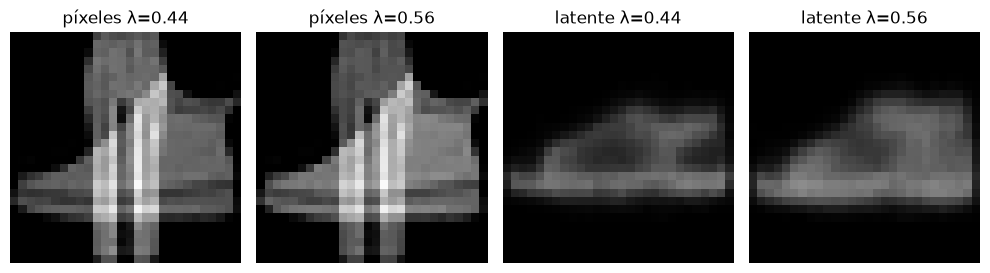

In [18]:
@torch.no_grad()
def dist_a_entrenamiento(imgs, lote=5000):
    # Distancia euclidiana (en píxeles) de cada imagen a la imagen de entrenamiento más cercana
    plano = imgs.flatten(1)
    mejores = torch.full((len(imgs),), float("inf"), device=device)
    for i in range(0, n_train, lote):
        d = torch.cdist(plano, X_train_d[i:i + lote].flatten(1))
        mejores = torch.minimum(mejores, d.min(1).values)
    return mejores


d_pix = dist_a_entrenamiento(interp_pix)
d_lat = dist_a_entrenamiento(interp_lat)
print(" λ    | dist. mín. a entrenamiento: píxeles | latente")
for l, a, b in zip(lambdas.flatten().tolist(), d_pix.tolist(), d_lat.tolist()):
    print(f" {l:.2f} | {a:35.3f} | {b:7.3f}")

# Ampliación de los dos puntos medios de cada interpolación
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for k, (img, tit) in enumerate([(interp_pix[4], "píxeles λ=0.44"), (interp_pix[5], "píxeles λ=0.56"),
                                (interp_lat[4], "latente λ=0.44"), (interp_lat[5], "latente λ=0.56")]):
    axes[k].imshow(img[0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[k].set_title(tit)
    axes[k].axis("off")
plt.tight_layout()
guardar("t1_4c_puntos_medios")

**Respuesta 1.4(c).**

**Región no reconocible.** En la cuadrícula $15\times15$ (Task 1.3b) hay dos tipos de zonas donde el decoder produce imágenes que no son prendas:

1. **El borde izquierdo, entre los cúmulos de *Pantalón* y *Zapatilla*.** Alrededor de $z\approx(-3\ \text{a}\ -2,\ -1.3\ \text{a}\ -0.9)$ aparece la superposición de un pantalón con la suela de una zapatilla, con artefactos.
2. **Los bordes y esquinas de $[-3,3]^2$.** Ahí el decoder solo repite y deforma la prenda más cercana: zapatillas idénticas en la esquina superior izquierda, bolsos/abrigos difusos arriba a la derecha.

La figura de cobertura explica por qué ocurre. **80 de los 225 nodos no tienen ninguna $\mu$ de validación a menos de 0.2**, y todos están fuera del disco $\lVert z\rVert\le2$: dentro de $\lVert z\rVert\le2$ hay 0 nodos vacíos, mientras que en $\lVert z\rVert\le3$ hay 15. Solo el 13.9 % de las $\mu$ tiene $\lVert\mu\rVert>2$, y apenas el 0.9 % tiene $\lVert\mu\rVert>3$. Así, el decoder nunca fue entrenado con $z$ de esas regiones y su salida ahí es una extrapolación.

**Explicación con el término KL y $\beta$.** La KL, $\tfrac12\sum_j(\mu_j^2+\sigma_j^2-1-\log\sigma_j^2)$, empuja cada posterior hacia $\mathcal N(0,I)$:
- El término $\mu_j^2$ concentra las codificaciones cerca del origen, y por eso los bordes quedan vacíos.
- El término $\sigma_j^2-\log\sigma_j^2$ pide $\sigma_j^2\to1$, para que los posteriores se traslapen y llenen el espacio.

Con $\beta=1$, la reconstrucción gana esta negociación: el modelo paga 5.25 nats por imagen para mantener posteriores muy angostos, con $\sigma^2\approx0.009$, es decir $\sigma\approx0.095$. Cada imagen ocupa un “punto” de radio ≈ 0.1. El decoder solo ve $z$ a unas pocas $\sigma$ de alguna $\mu$, así que las fronteras entre clases y las colas del prior quedan sin entrenar.

Un $\beta$ mayor llena más el espacio. Con $\beta=10$, $\sigma^2\approx0.24$ y $0.16$, y la nube de $\mu$ se contrae a aproximadamente $[-2,\,2.7]^2$, pero a cambio pierde información (respuesta 1.4a). Con $\beta=0.1$, $\sigma^2\approx0.001$ y las $\mu$ llegan hasta $\pm4$, lo que deja aún más huecos. Eso explica las muestras oscuras y fantasmales que se ven en 1.3(c) para $\beta=0.1$.

**Puntos medios de las interpolaciones** (Pantalón → Botín, $\lambda=0.44$ y $0.56$):
- **En píxeles:** se ven **dos prendas superpuestas y semitransparentes**: el pantalón y el botín a la vez, cada uno con la mitad de intensidad. No es una prenda. Su distancia a la imagen de entrenamiento más cercana es la **máxima de todo el recorrido (5.36 y 5.19)**, frente a 1.88 y 3.55 en los extremos.
- **En latente:** se ve **una sola silueta de calzado** (una sandalia o zapato bajo), borrosa y de bajo contraste. Su distancia a la imagen de entrenamiento más cercana es 2.58 y 2.60, del mismo orden que las reconstrucciones de los extremos (1.81 y 2.40).

**Por qué difieren.** El conjunto de imágenes reales no es convexo en $\mathbb R^{784}$: el promedio de dos imágenes reales no es una imagen real. En cambio, el decoder lleva cada punto del segmento entre $\mu_a$ y $\mu_b$ a la variedad que aprendió, así que siempre produce algo parecido a una prenda. El resultado es una transición semántica pantalón → (vestido/sandalia) → zapato → botín, no un fundido de intensidades.

La interpolación latente también es borrosa y oscura en $\lambda\approx0.22$–$0.56$. El segmento atraviesa la zona cercana a $(-0.8,\,-0.4\ \text{a}\ 0.3)$, donde se tocan los cúmulos de pantalón, vestido y sandalia. Ahí el decoder promedia clases distintas, la misma razón por la que el centro de la cuadrícula se ve tenue.

### d. Nitidez de las muestras

**Definición.** La nitidez es la magnitud media de la diferencia entre píxeles horizontalmente adyacentes, $\frac{1}{N\cdot 28\cdot 27}\sum|x_{i,j+1}-x_{i,j}|$, calculada en la escala $[0,1]$. Se mide sobre 1 000 imágenes reales de validación y sobre 1 000 imágenes generadas con $z\sim\mathcal N(0,I)$ para cada $\beta$.

In [19]:
def nitidez(imgs):
    # Magnitud media de la diferencia entre píxeles horizontalmente adyacentes: mean |x[..., j+1] − x[..., j]|
    # (se espera recibir imágenes en [0,1]; las de difusión en [−1,1] deben reescalarse con (x+1)/2)
    return (imgs[..., :, 1:] - imgs[..., :, :-1]).abs().mean().item()


g_nit = torch.Generator(device=device).manual_seed(SEED)
z_1000 = torch.randn(1000, latent_dim, device=device, generator=g_nit)   # z ~ N(0, I)
nit = {"reales (validación)": nitidez(X_val_d[:1000])}
with torch.no_grad():
    for beta in beta_values:
        nit[f"VAE β={beta}"] = nitidez(modelos[beta].decode(z_1000))

for k, v in nit.items():
    print(f"{k:>22}: nitidez = {v:.4f}  ({100 * v / nit['reales (validación)']:.1f} % de la real)")

# Referencia adicional: nitidez de las reconstrucciones decoder(μ) de las mismas 1 000 imágenes reales.
# Separa el desenfoque propio del decoder del efecto de muestrear z en zonas poco cubiertas del prior.
print("\nReconstrucciones decoder(μ(x)) de las 1 000 imágenes reales:")
with torch.no_grad():
    for beta in beta_values:
        mu_r, _ = modelos[beta].encode(X_val_d[:1000])
        v = nitidez(modelos[beta].decode(mu_r))
        print(f"{'VAE β=' + str(beta):>22}: nitidez = {v:.4f}  ({100 * v / nit['reales (validación)']:.1f} % de la real)")

   reales (validación): nitidez = 0.0891  (100.0 % de la real)
             VAE β=0.1: nitidez = 0.0466  (52.3 % de la real)
             VAE β=1.0: nitidez = 0.0501  (56.2 % de la real)
            VAE β=10.0: nitidez = 0.0442  (49.6 % de la real)

Reconstrucciones decoder(μ(x)) de las 1 000 imágenes reales:
             VAE β=0.1: nitidez = 0.0555  (62.2 % de la real)
             VAE β=1.0: nitidez = 0.0547  (61.3 % de la real)
            VAE β=10.0: nitidez = 0.0452  (50.7 % de la real)


**Relación entre $\mathcal L_\beta$ y un decoder gaussiano.** Si $p_\theta(x\mid z)=\mathcal N(x;\hat x(z),\sigma_x^2 I)$ con $D=784$ píxeles:
$$-\log p_\theta(x\mid z)=\frac{\lVert x-\hat x\rVert^2}{2\sigma_x^2}+\frac D2\log(2\pi\sigma_x^2)$$
Entonces, la ELBO negativa (Derivación 4) es
$$-\mathcal L_{\text{ELBO}}=\frac{\lVert x-\hat x\rVert^2}{2\sigma_x^2}+D_{KL}+\text{cte}.$$
Al multiplicar por $2\sigma_x^2>0$, lo que no cambia el minimizador, queda
$$2\sigma_x^2\left(-\mathcal L_{\text{ELBO}}\right)=\lVert x-\hat x\rVert^2+2\sigma_x^2\,D_{KL}+\text{cte}.$$
Si se compara término a término con $\mathcal L_\beta=\lVert x-\hat x\rVert^2+\beta D_{KL}$, ambos objetivos coinciden cuando
$$\beta=2\sigma_x^2\quad\Longleftrightarrow\quad\boxed{\sigma_x^2=\beta/2}.$$

**Respuesta 1.4(d).**

| Imágenes (1 000 c/u) | Nitidez | % de la real |
|---|---:|---:|
| Reales (validación) | **0.0891** | 100 % |
| VAE $\beta=0.1$, $z\sim\mathcal N(0,I)$ | **0.0466** | 52.3 % |
| VAE $\beta=1$, $z\sim\mathcal N(0,I)$ | **0.0501** | 56.2 % |
| VAE $\beta=10$, $z\sim\mathcal N(0,I)$ | **0.0442** | 49.6 % |
| _Referencia:_ reconstrucciones decoder($\mu$), $\beta=0.1/1/10$ | 0.0555 / 0.0547 / 0.0452 | 62 / 61 / 51 % |

**Relación $\sigma_x^2=\beta/2$.** Como se mostró arriba, multiplicar la ELBO negativa de un decoder gaussiano por $2\sigma_x^2$ da $\lVert x-\hat x\rVert^2+2\sigma_x^2 D_{KL}$. Si se iguala con $\mathcal L_\beta$, resulta $\beta=2\sigma_x^2$, o sea $\sigma_x^2=\beta/2$. Nuestros tres modelos equivalen entonces a decoders gaussianos con:

| $\beta$ | $\sigma_x^2$ | $\sigma_x$ |
|---:|---:|---:|
| 0.1 | 0.05 | 0.22 |
| 1 | 0.5 | 0.71 |
| 10 | 5 | 2.24 |

Esas desviaciones estándar se comparan con píxeles en $[0,1]$.

**Por qué las muestras salen borrosas.** El modelo supone que $x=\hat x(z)+\text{ruido}$, con un ruido por píxel de desviación $\sigma_x$. Con $\beta=1$, $\sigma_x\approx0.71$, más de dos tercios del rango dinámico. Todo detalle de alta frecuencia (bordes, costuras, estampados, texturas) cabe dentro de ese “ruido” y no se penaliza explicarlo como ruido. Además, lo que mostramos es la **media** $\hat x(z)$, no una muestra de $p(x\mid z)$. Bajo pérdida cuadrática, el decoder óptimo es $\hat x(z)=\mathbb E[x\mid z]$: el promedio de todas las imágenes que el encoder envía cerca de $z$. Un promedio de prendas con bordes en posiciones ligeramente distintas tiene bordes suaves. Con un código de solo 2 dimensiones (5–8 bits, ver 1.4a), cada $z$ corresponde a muchas imágenes distintas, así que ese promedio es muy amplio.

Los números lo confirman:
- Todas las muestras tienen **la mitad de la nitidez real** (49.6–56.2 %). Incluso las reconstrucciones de imágenes reales llegan solo al 51–62 %, así que la pérdida de nitidez está en el propio decoder.
- Con $\beta=10$ ($\sigma_x\approx2.24$) la nitidez es la menor, tanto en muestras (0.0442) como en reconstrucciones (0.0452).
- $\beta=0.1$ ($\sigma_x\approx0.22$) reconstruye con la mayor nitidez (0.0555), pero sus **muestras** del prior (0.0466) son menos nítidas que las de $\beta=1$ (0.0501). Al tener posteriores muy angostos y la nube de $\mu$ extendida hasta $\pm4$ (1.4c), muchas $z\sim\mathcal N(0,I)$ caen en huecos donde el decoder produce manchas oscuras.

En resumen, bajar $\beta$ (reducir $\sigma_x$) mejora la nitidez de las reconstrucciones, pero agranda el desajuste entre el prior y las codificaciones. Ningún valor de $\beta$ acerca las muestras a la nitidez real.